# New Idea
Now I train the resnet before with a mix of siamese and autoencoder parts

In [1]:
from MLChess import build_and_save_trajectories, SiameseChessDataset, FullChessModel
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import numpy as np
import h5py

In [2]:
dataset = SiameseChessDataset("mate_trajectories.h5", n_pairs=1000)
board_a, board_b, label = dataset[0]
print(f"Board A shape: {board_a.shape}")   # atteso (13, 8, 8)
print(f"Board B shape: {board_b.shape}")   # atteso (13, 8, 8)
print(f"Label: {label}")                   # 0.0 o 1.0
print(f"Coppie positive: {sum(p[4] for p in dataset.pairs)}")
print(f"Coppie negative: {sum(1 - p[4] for p in dataset.pairs)}")

Board A shape: torch.Size([13, 8, 8])
Board B shape: torch.Size([13, 8, 8])
Label: 0.0
Coppie positive: 500.0
Coppie negative: 500.0


In [3]:
model = FullChessModel()

board_a = torch.randn(4, 13, 8, 8)
board_b = torch.randn(4, 13, 8, 8)

z_sem_a, z_sem_b, recon_a, recon_b, _, _ = model.forward_phase1(board_a, board_b)
print(f"z_sem shape: {z_sem_a.shape}")    # atteso (4, 256)
print(f"recon shape: {recon_a.shape}")    # atteso (4, 13, 8, 8)

z_sem shape: torch.Size([4, 256])
recon shape: torch.Size([4, 13, 8, 8])


In [2]:
class SiameseLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, z_a, z_b, label):
        dist = F.pairwise_distance(z_a, z_b)
        loss = label * dist.pow(2) + (1 - label) * F.relu(self.margin - dist).pow(2)
        return loss.mean()

In [15]:
def train_phase1(
    model: FullChessModel,
    h5_path: str = "mate_trajectories.h5",
    n_pairs: int = 300_000,
    epochs: int = 30,
    batch_size: int = 256,
    lr: float = 3e-4,
    lambda_siamese: float = 1.0,
    lambda_recon: float = 0.5,
    checkpoint_path: str = None,
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
):
    model = model.to(device)

    full_dataset = SiameseChessDataset(h5_path, n_pairs=n_pairs)
    val_size = int(len(full_dataset) * 0.1)
    train_size = len(full_dataset) - val_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    siamese_loss_fn = SiameseLoss(margin=1.0)

    start_epoch = 0
    best_val_loss = float('inf')

    # Riprendi da checkpoint se fornito
    if checkpoint_path is not None:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']
        best_val_loss = checkpoint.get('best_val_loss', float('inf'))
        print(f"Ripreso da epoch {start_epoch}, best_val_loss={best_val_loss:.4f}")

    def save_checkpoint(path, epoch, is_best=False):
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_loss': val_total,
            'val_siamese': val_siamese,
            'val_recon': val_recon,
            'best_val_loss': best_val_loss,
        }, path)
        if is_best:
            print(f"  → Salvato nuovo best model (val_loss={val_total:.4f})")

    for epoch in range(start_epoch, epochs):
        # --- Training ---
        model.train()
        train_siamese, train_recon, train_total = 0.0, 0.0, 0.0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for board_a, board_b, label in train_bar:
            board_a = board_a.to(device)
            board_b = board_b.to(device)
            label = label.to(device)

            optimizer.zero_grad()

            z_sem_a, z_sem_b, recon_a, recon_b, orig_a, orig_b = model.forward_phase1(board_a, board_b)

            loss_s = siamese_loss_fn(z_sem_a, z_sem_b, label)
            loss_r = F.binary_cross_entropy(recon_a, orig_a) + \
                    F.binary_cross_entropy(recon_b, orig_b)
            loss = lambda_siamese * loss_s + lambda_recon * loss_r

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_siamese += loss_s.item()
            train_recon += loss_r.item()
            train_total += loss.item()

            # Aggiorna la barra con le loss correnti
            train_bar.set_postfix({
                'total': f'{loss.item():.4f}',
                'siam': f'{loss_s.item():.4f}',
                'recon': f'{loss_r.item():.4f}',
            })

        n_train = len(train_loader)
        train_siamese /= n_train
        train_recon /= n_train
        train_total /= n_train

        # --- Validation ---
        model.eval()
        val_siamese, val_recon, val_total = 0.0, 0.0, 0.0

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]  ", leave=False)
        with torch.no_grad():
            for board_a, board_b, label in val_bar:
                board_a = board_a.to(device)
                board_b = board_b.to(device)
                label = label.to(device)

                z_sem_a, z_sem_b, recon_a, recon_b, orig_a, orig_b = model.forward_phase1(board_a, board_b)

                loss_s = siamese_loss_fn(z_sem_a, z_sem_b, label)
                loss_r = F.binary_cross_entropy(recon_a, orig_a) + \
                        F.binary_cross_entropy(recon_b, orig_b)
                loss = lambda_siamese * loss_s + lambda_recon * loss_r

                val_siamese += loss_s.item()
                val_recon += loss_r.item()
                val_total += loss.item()

                val_bar.set_postfix({
                    'total': f'{loss.item():.4f}',
                    'siam': f'{loss_s.item():.4f}',
                    'recon': f'{loss_r.item():.4f}',
                })

        n_val = len(val_loader)
        val_siamese /= n_val
        val_recon /= n_val
        val_total /= n_val

        scheduler.step(val_total)

        # Stampa riassunto epoca
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{epochs} | LR: {current_lr:.2e} | "
            f"Train — total: {train_total:.4f} siam: {train_siamese:.4f} recon: {train_recon:.4f} | "
            f"Val — total: {val_total:.4f} siam: {val_siamese:.4f} recon: {val_recon:.4f}")

        # Salva sempre l'ultimo
        save_checkpoint("chess_phase1_last.pt", epoch + 1)

        # Salva il migliore
        if val_total < best_val_loss:
            best_val_loss = val_total
            save_checkpoint("chess_phase1_best.pt", epoch + 1, is_best=True)

    print("Fase 1 completata.")
    return model

In [16]:
# Prima esecuzione
model = FullChessModel()
model = train_phase1(
    model,
    h5_path="mate_trajectories.h5",
    n_pairs=500_000,
    epochs=30,
    batch_size=512,
    lr=3e-4,
    lambda_siamese=1.0,
    lambda_recon=0.5,
)

'''
# Ripresa da ultimo checkpoint
model = FullChessModel()
model = train_phase1(model, checkpoint_path="chess_phase1_last.pt")

# Ripresa dal migliore
model = FullChessModel()
model = train_phase1(model, checkpoint_path="chess_phase1_best.pt")
'''

Epoch   1/30 | LR: 3.00e-04 | Train — total: 2.2564 siam: 2.1790 recon: 0.1547 | Val — total: 0.0623 siam: 0.0104 recon: 0.1038
  → Salvato nuovo best model (val_loss=0.0623)


Epoch   2/30 | LR: 3.00e-04 | Train — total: 0.0578 siam: 0.0116 recon: 0.0924 | Val — total: 0.0477 siam: 0.0068 recon: 0.0818
  → Salvato nuovo best model (val_loss=0.0477)


Epoch   3/30 | LR: 3.00e-04 | Train — total: 0.0444 siam: 0.0085 recon: 0.0719 | Val — total: 0.0374 siam: 0.0058 recon: 0.0633
  → Salvato nuovo best model (val_loss=0.0374)


Epoch   4/30 | LR: 3.00e-04 | Train — total: 0.0357 siam: 0.0069 recon: 0.0576 | Val — total: 0.0291 siam: 0.0047 recon: 0.0487
  → Salvato nuovo best model (val_loss=0.0291)


Epoch   5/30 | LR: 3.00e-04 | Train — total: 0.0286 siam: 0.0060 recon: 0.0452 | Val — total: 0.0208 siam: 0.0046 recon: 0.0324
  → Salvato nuovo best model (val_loss=0.0208)


...

Epoch  27/30 | LR: 3.00e-04 | Train — total: 0.0012 siam: 0.0009 recon: 0.0007 | Val — total: 0.0014 siam: 0.0013 recon: 0.0002
  → Salvato nuovo best model (val_loss=0.0014)


Epoch  28/30 | LR: 3.00e-04 | Train — total: 0.0008 siam: 0.0007 recon: 0.0002 | Val — total: 0.0014 siam: 0.0013 recon: 0.0002
  → Salvato nuovo best model (val_loss=0.0014)


Epoch  29/30 | LR: 3.00e-04 | Train — total: 0.0008 siam: 0.0006 recon: 0.0003 | Val — total: 0.0016 siam: 0.0013 recon: 0.0005


Epoch  30/30 | LR: 3.00e-04 | Train — total: 0.0008 siam: 0.0007 recon: 0.0003 | Val — total: 0.0016 siam: 0.0013 recon: 0.0005
Fase 1 completata.


'\n# Ripresa da ultimo checkpoint\nmodel = FullChessModel()\nmodel = train_phase1(model, checkpoint_path="chess_phase1_last.pt")\n\n# Ripresa dal migliore\nmodel = FullChessModel()\nmodel = train_phase1(model, checkpoint_path="chess_phase1_best.pt")\n'

In [3]:
model = FullChessModel()

checkpoint = torch.load("chess_phase1_best.pt")
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [4]:
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

dataset = SiameseChessDataset("mate_trajectories.h5", n_pairs=2000, seed=99)
loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)

pos_dists, neg_dists = [], []

with torch.no_grad():
    for board_a, board_b, label in loader:
        board_a, board_b = board_a.to(device), board_b.to(device)
        z_sem_a, z_sem_b, _, _, _, _ = model.forward_phase1(board_a, board_b)
        dists = F.pairwise_distance(z_sem_a, z_sem_b).cpu()
        for d, l in zip(dists, label):
            if l == 1.0:
                pos_dists.append(d.item())
            else:
                neg_dists.append(d.item())

print(f"Coppie positive — media: {np.mean(pos_dists):.4f}, std: {np.std(pos_dists):.4f}")
print(f"Coppie negative — media: {np.mean(neg_dists):.4f}, std: {np.std(neg_dists):.4f}")
print(f"Separazione: {np.mean(neg_dists) / np.mean(pos_dists):.1f}x")

Coppie positive — media: 0.0240, std: 0.0182
Coppie negative — media: 1.7362, std: 0.3582
Separazione: 72.2x


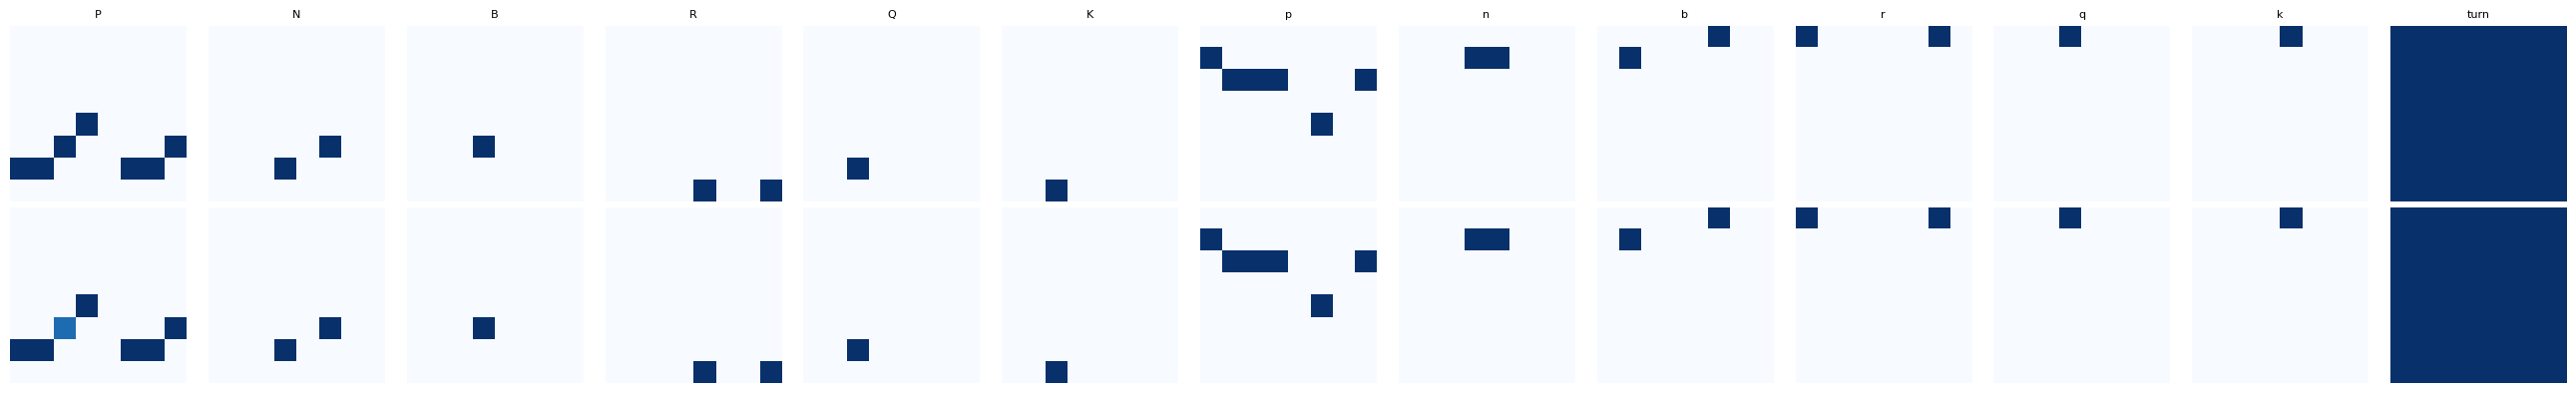

In [5]:
import matplotlib.pyplot as plt

# Prendi una board dal dataset
with h5py.File("mate_trajectories.h5", 'r') as f:
    sample = torch.tensor(f["traj_0"][0], dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    z = model.backbone(sample)
    recon = model.decoder(z)

# Confronta originale e ricostruzione per ogni piano
piece_names = ['P','N','B','R','Q','K','p','n','b','r','q','k','turn']

fig, axes = plt.subplots(2, 13, figsize=(26, 4))
for i in range(13):
    axes[0, i].imshow(sample[0, i].cpu(), cmap='Blues', vmin=0, vmax=1)
    axes[0, i].set_title(piece_names[i], fontsize=8)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(recon[0, i].cpu(), cmap='Blues', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Originale", fontsize=8)
axes[1, 0].set_ylabel("Ricostruita", fontsize=8)
plt.tight_layout()
plt.savefig("reconstruction_check.png", dpi=150)
plt.show()

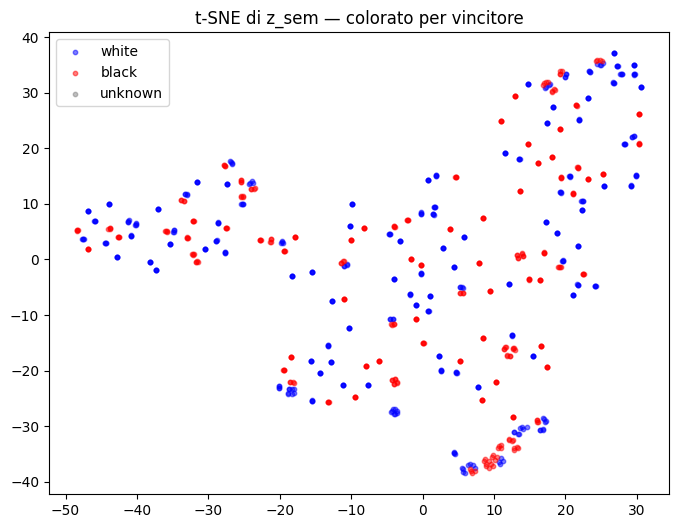

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

embeddings, colors = [], []
color_map = {'white': 'blue', 'black': 'red', 'unknown': 'gray'}

with h5py.File("mate_trajectories.h5", 'r') as f:
    n_traj = f.attrs["n_trajectories"]
    # Campiona 200 traiettorie
    indices = np.random.choice(n_traj, size=200, replace=False)
    
    boards, winners = [], []
    for i in indices:
        traj = f[f"traj_{i}"]
        winner = traj.attrs["winner"]
        for j in range(traj.shape[0]):
            boards.append(torch.tensor(traj[j], dtype=torch.float32))
            winners.append(winner)

boards = torch.stack(boards).to(device)

with torch.no_grad():
    z = model.backbone(boards)
    z_sem = z[:, :256].cpu().numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_2d = tsne.fit_transform(z_sem)

plt.figure(figsize=(8, 6))
for winner, color in color_map.items():
    mask = [w == winner for w in winners]
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], c=color, label=winner, alpha=0.5, s=10)
plt.legend()
plt.title("t-SNE di z_sem — colorato per vincitore")
plt.savefig("tsne_zsem.png", dpi=150)
plt.show()